# 03 — Entanglement defines geometry

**Manuscript:** Part IV §2.3, §6.

$I(A:B) = S(A) + S(B) - S(A\cup B)$; effective distance $d(A,B) \sim -\log I(A:B)$; Ryu–Takayanagi toy: $S(A) \propto$ boundary size.

*Note:* $d_{\mathrm{eff}}$ is in nats and can be negative when $I(A:B) > 1$ (e.g. Bell pair).

In [1]:
import os, sys
cwd = os.getcwd()
root = os.path.dirname(cwd) if os.path.basename(cwd) == 'notebooks' else cwd
if root not in sys.path:
    sys.path.insert(0, root)
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from src.entanglement_geometry import from_qiskit_statevector, rt_toy_entropy_vs_boundary
from src import tensor_network as tn
import quimb.tensor as qtn

# Bell pair: qubits 0 and 1
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
sv = Statevector.from_instruction(qc)
qubits_A, qubits_B = [0], [1]
(S_A, S_B, S_AB, I_AB, d_eff), _ = from_qiskit_statevector(sv, qubits_A, qubits_B)
print(f'Bell pair: A={qubits_A}, B={qubits_B}')
print(f'  S(A)={S_A:.4f}, S(B)={S_B:.4f}, S(AB)={S_AB:.4f}')
print(f'  I(A:B)={I_AB:.4f}, d_eff={d_eff:.4f}')

Bell pair: A=[0], B=[1]
  S(A)=0.6931, S(B)=0.6931, S(AB)=0.0000
  I(A:B)=1.3863, d_eff=-0.3266


In [2]:
# RT toy: MPS entropy vs boundary (1D: one bond per cut)
psi = qtn.MPS_ghz_state(6)
rt_data = rt_toy_entropy_vs_boundary(psi)
print('Ryu–Takayanagi toy (GHZ chain): S(A) vs n_sites in A')
for n_sites, S in rt_data:
    print(f'  n_sites_A={n_sites} -> S={S:.4f}')

Ryu–Takayanagi toy (GHZ chain): S(A) vs n_sites in A
  n_sites_A=1 -> S=0.6931
  n_sites_A=2 -> S=0.6931
  n_sites_A=3 -> S=0.6931
  n_sites_A=4 -> S=0.6931
  n_sites_A=5 -> S=0.6931


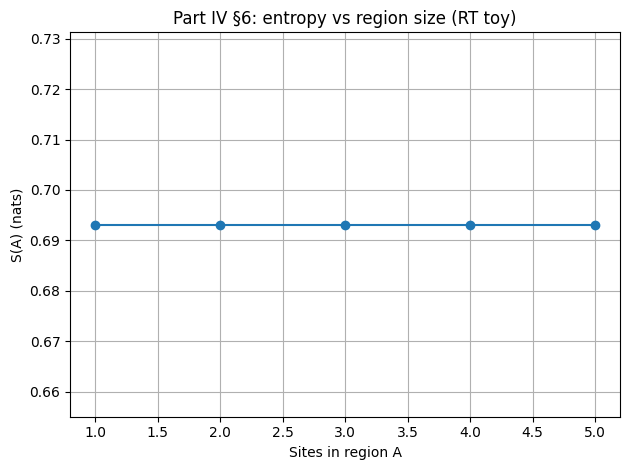

In [3]:
import matplotlib.pyplot as plt

sites = [x[0] for x in rt_data]
entropies = [x[1] for x in rt_data]
plt.plot(sites, entropies, 'o-')
plt.xlabel('Sites in region A')
plt.ylabel('S(A) (nats)')
plt.title('Part IV §6: entropy vs region size (RT toy)')
plt.grid(True)
plt.tight_layout()
plt.show()

**RT toy with rainbow state:** For the manuscript's area law ($S \propto$ boundary), entropy should scale with the number of bonds cut. The rainbow MPS (Bell pairs across the cut) has $S = |\gamma| \log d$ at each bond, so $S$ grows with boundary size (then decreases toward the other end). Below: same RT toy with rainbow state.

In [ ]:
# Rainbow MPS: S scales with number of bonds cut (area law toy)
psi_rainbow, _ = tn.verify_s_equals_gamma_log_d_rainbow(6)
rt_data_rainbow = rt_toy_entropy_vs_boundary(psi_rainbow)
print('Ryu–Takayanagi toy (rainbow chain): S(A) vs n_sites in A')
for n_sites, S in rt_data_rainbow:
    print(f'  n_sites_A={n_sites} -> S={S:.4f}')

In [ ]:
plt.figure()
sites_r = [x[0] for x in rt_data_rainbow]
entropies_r = [x[1] for x in rt_data_rainbow]
plt.plot(sites_r, entropies_r, 'o-', label='rainbow (S ∝ |γ|)')
plt.xlabel('Sites in region A')
plt.ylabel('S(A) (nats)')
plt.title('Part IV §6: entropy vs region (rainbow — area law toy)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()